# Minería de datos 2027-1
### Procesamiento de datos con Pyspark
##### Autor: Ulises Olivares
##### uolivares@unam.mx
##### 09 de septiembre de 2026


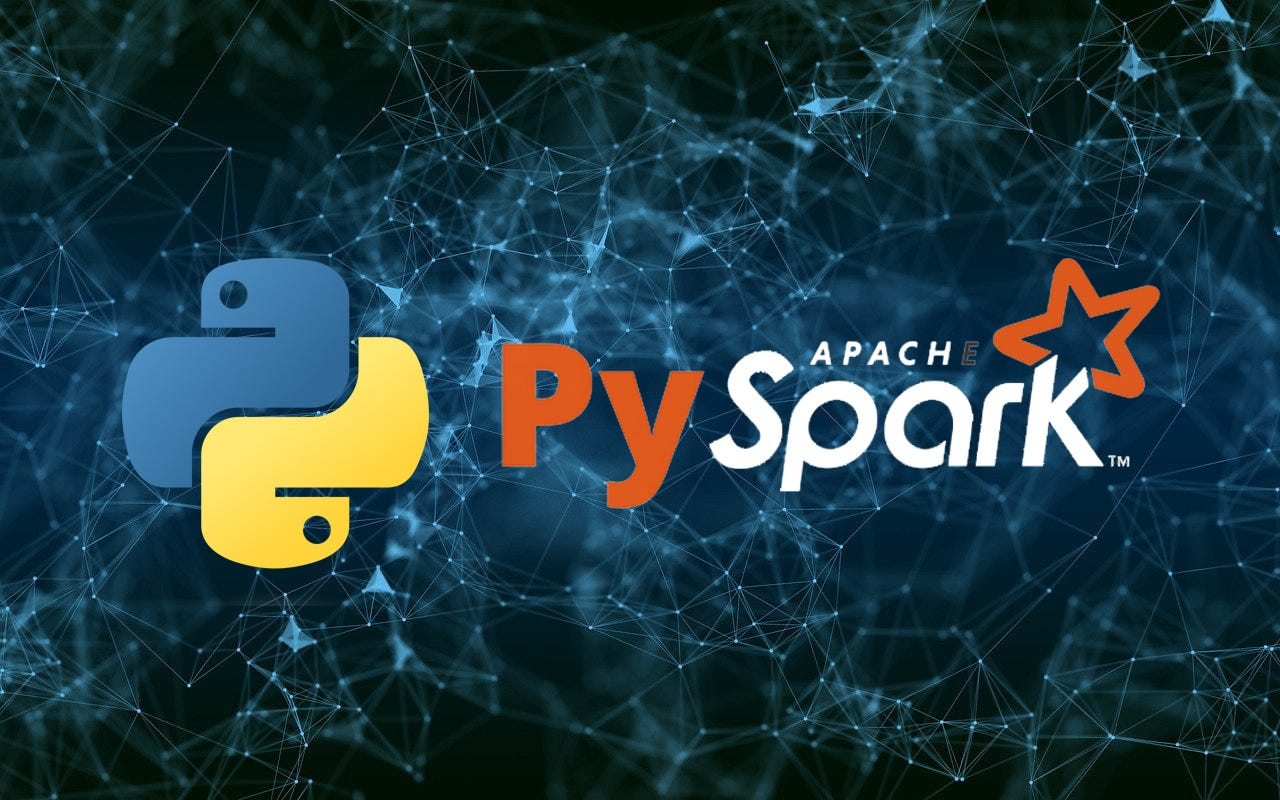

## preparación del entorno

In [ ]:
# opcional: instala pyspark si no está disponible (en colab generalmente no es necesario)
# descomente si lo requiere
#!pip install -q pyspark==3.5.1


## iniciar spark session

In [1]:
from pyspark.sql import SparkSession
spark = (SparkSession.builder
         .appName("clase-pyspark-procesamiento")
         .getOrCreate())

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/09 11:10:08 WARN Utils: Your hostname, nixos, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/09 11:10:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/nixos/repos/data-mining/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/09 11:10:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


0. Is PySpark built upon on Java? I got PySparkRuntimeError: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.
1. How many datatypes does PySpark have? Do these connect well with numpy data types? 
2. It seems that Spark allow us to use CUDA underneath. 
3. Parquet is mainly used for compriming information, as it changes the format of the plain text to a binary representation that is able to be decompressed later. 


## crear datos de ejemplo en memoria
vamos a construir un dataframe a partir de una lista de diccionarios para practicar transformaciones básicas.

In [2]:
from pyspark.sql import functions as F, types as T

datos = [
    {"id": 1, "ciudad": "querétaro", "ventas": 1200.5, "fecha": "2025-08-31"},
    {"id": 2, "ciudad": "cdmx", "ventas": 2300.0, "fecha": "2025-09-01"},
    {"id": 3, "ciudad": "león", "ventas": None, "fecha": "2025-09-01"},
    {"id": 4, "ciudad": "cdmx", "ventas": 450.0, "fecha": "2025-09-02"},
    {"id": 5, "ciudad": "querétaro", "ventas": 900.0, "fecha": "2025-09-03"},
]

df = spark.createDataFrame(datos)
df.show()
df.printSchema()


+---------+----------+---+------+
|   ciudad|     fecha| id|ventas|
+---------+----------+---+------+
|querétaro|2025-08-31|  1|1200.5|
|     cdmx|2025-09-01|  2|2300.0|
|     león|2025-09-01|  3|  NULL|
|     cdmx|2025-09-02|  4| 450.0|
|querétaro|2025-09-03|  5| 900.0|
+---------+----------+---+------+

root
 |-- ciudad: string (nullable = true)
 |-- fecha: string (nullable = true)
 |-- id: long (nullable = true)
 |-- ventas: double (nullable = true)



## transformaciones y acciones básicas

In [3]:
# seleccionar columnas, renombrar, crear nuevas columnas y filtrar
df2 = (df
       .select(F.col("id").alias("cliente_id"),
               "ciudad",
               F.col("ventas").cast("double"),
               F.to_date("fecha").alias("fecha"))
       .withColumn("ventas_con_impuesto", F.col("ventas") * 1.16)
       .filter(F.col("ventas").isNotNull()))
df2.show()


+----------+---------+------+----------+-------------------+
|cliente_id|   ciudad|ventas|     fecha|ventas_con_impuesto|
+----------+---------+------+----------+-------------------+
|         1|querétaro|1200.5|2025-08-31|            1392.58|
|         2|     cdmx|2300.0|2025-09-01|             2668.0|
|         4|     cdmx| 450.0|2025-09-02|              522.0|
|         5|querétaro| 900.0|2025-09-03|             1044.0|
+----------+---------+------+----------+-------------------+



## manejo de valores faltantes

In [4]:
# imputar valores faltantes de 'ventas' con la media
prom_ventas = df.select(F.mean("ventas")).first()[0]
df_imputado = df.fillna({"ventas": float(prom_ventas)})
df_imputado.show()


+---------+----------+---+--------+
|   ciudad|     fecha| id|  ventas|
+---------+----------+---+--------+
|querétaro|2025-08-31|  1|  1200.5|
|     cdmx|2025-09-01|  2|  2300.0|
|     león|2025-09-01|  3|1212.625|
|     cdmx|2025-09-02|  4|   450.0|
|querétaro|2025-09-03|  5|   900.0|
+---------+----------+---+--------+



## agregaciones y groupby

In [5]:
aggs = (df_imputado
        .groupBy("ciudad")
        .agg(F.count("*").alias("n"),
             F.round(F.sum("ventas"),2).alias("ventas_totales"),
             F.round(F.avg("ventas"),2).alias("ventas_promedio"))
       )
aggs.show()


+---------+---+--------------+---------------+
|   ciudad|  n|ventas_totales|ventas_promedio|
+---------+---+--------------+---------------+
|querétaro|  2|        2100.5|        1050.25|
|     cdmx|  2|        2750.0|         1375.0|
|     león|  1|       1212.63|        1212.63|
+---------+---+--------------+---------------+



## escribir y leer csv y parquet

In [6]:
# guardamos a disco (en colab se escribe en /content; en local, en el cwd)
import os, shutil, tempfile
base = "/content/"
csv_path = os.path.join(base, "ventas.csv")
parquet_path = os.path.join(base, "ventas.parquet")

(df_imputado
 .coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(csv_path))

df_csv = spark.read.option("header", True).csv(csv_path, inferSchema=True)
df_csv.show(5)

df_imputado.write.mode("overwrite").parquet(parquet_path)
df_parquet = spark.read.parquet(parquet_path)
df_parquet.show(5)

base


26/09/09 11:10:51 ERROR FileOutputCommitter: Mkdirs failed to create file:/content/ventas.csv/_temporary/0
26/09/09 11:10:51 ERROR Utils: Aborting task
java.io.IOException: Mkdirs failed to create file:/content/ventas.csv/_temporary/0/_temporary/attempt_202609091110516336820393963343416_0015_m_000000_62 (exists=false, cwd=file:/home/nixos/repos/data-mining)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:774)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:759)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1234)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1211)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1092)
	at org.apache.spark.sql.execution.datasources.CodecStreams$.createOutputStream(CodecStreams.scala:72)
	at org.apache.spark.sql.execution.datasources.CodecStreams$.createOutputStreamWriter(CodecStreams.scala:83)
	at org.apache.spark.sql.execution.datasources.csv.CsvOutputWriter.<init>

Py4JJavaError: An error occurred while calling o117.csv.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 15.0 failed 1 times, most recent failure: Lost task 0.0 in stage 15.0 (TID 62) (10.255.255.254 executor driver): java.io.IOException: Mkdirs failed to create file:/content/ventas.csv/_temporary/0/_temporary/attempt_202609091110516336820393963343416_0015_m_000000_62 (exists=false, cwd=file:/home/nixos/repos/data-mining)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:774)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:759)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1234)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1211)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1092)
	at org.apache.spark.sql.execution.datasources.CodecStreams$.createOutputStream(CodecStreams.scala:72)
	at org.apache.spark.sql.execution.datasources.CodecStreams$.createOutputStream

In [7]:
csv_path

'/content/ventas.csv'

## joins entre dataframes

In [8]:
# creamos un catálogo de ciudades con regiones
cat = spark.createDataFrame([
    ("cdmx", "centro"),
    ("querétaro", "bajío"),
    ("león", "bajío"),
], ["ciudad", "region"])

left = df_imputado.join(cat, on="ciudad", how="left")
left.show()


+---------+----------+---+--------+------+
|   ciudad|     fecha| id|  ventas|region|
+---------+----------+---+--------+------+
|querétaro|2025-08-31|  1|  1200.5| bajío|
|     cdmx|2025-09-01|  2|  2300.0|centro|
|     león|2025-09-01|  3|1212.625| bajío|
|     cdmx|2025-09-02|  4|   450.0|centro|
|querétaro|2025-09-03|  5|   900.0| bajío|
+---------+----------+---+--------+------+



## ventanas: ranking y promedio móvil

In [9]:
from pyspark.sql.window import Window

w = Window.partitionBy("ciudad").orderBy(F.col("fecha").cast("date"))
df_win = (df_imputado.withColumn("ventas_filled", F.col("ventas"))
          .withColumn("rank_ciudad", F.row_number().over(w))
          .withColumn("prom_movil_2",
                      F.avg("ventas_filled").over(w.rowsBetween(-1, 0)))
         )
df_win.orderBy("ciudad", "fecha").show()


+---------+----------+---+--------+-------------+-----------+------------+
|   ciudad|     fecha| id|  ventas|ventas_filled|rank_ciudad|prom_movil_2|
+---------+----------+---+--------+-------------+-----------+------------+
|     cdmx|2025-09-01|  2|  2300.0|       2300.0|          1|      2300.0|
|     cdmx|2025-09-02|  4|   450.0|        450.0|          2|      1375.0|
|     león|2025-09-01|  3|1212.625|     1212.625|          1|    1212.625|
|querétaro|2025-08-31|  1|  1200.5|       1200.5|          1|      1200.5|
|querétaro|2025-09-03|  5|   900.0|        900.0|          2|     1050.25|
+---------+----------+---+--------+-------------+-----------+------------+



## udf: funciones definidas por el usuario

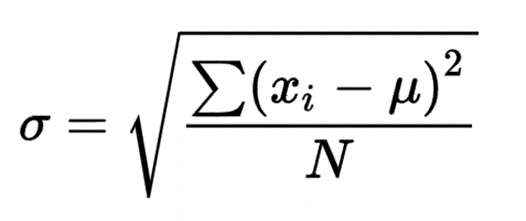

6. It is not recommended to use user-defined functions as we go out of the environment created by Spark, which seems that the main benefit it provides is automatic use of distributed and shared programming protocols. 

In [10]:
import math as m
# ejemplo: clasificar ticket como 'alto' si ventas > 1000
@F.udf(returnType=T.StringType())
def etiqueta_ticket(v):
    if v is None:
        return "desconocido"
    return "alto" if float(v) > 1000 else "bajo"

df_udf = df_imputado.withColumn("categoria_ticket", etiqueta_ticket("ventas"))

@F.udf(returnType=T.StringType())
def calc_std_dev(v):
    if v is None:
        return "desconocido"
    else:
        return str(round(m.sqrt((float(v))),2))
    # TODO calcular std dev


df_udf2 = df_udf.withColumn("std_dev", calc_std_dev("ventas"))

df_udf2.show()


/home/nixos/repos/data-mining/.venv/lib/python3.13/site-packages/pyspark/sql/udf.py:116: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/nixos/repos/data-mining/.venv/lib/python3.13/site-packages/pyspark/sql/udf.py:120: RuntimeWarning: Arrow optimization failed to enable because PyArrow or Pandas is not installed. Falling back to a non-Arrow-optimized UDF.
  warnings.warn(


+---------+----------+---+--------+----------------+-------+
|   ciudad|     fecha| id|  ventas|categoria_ticket|std_dev|
+---------+----------+---+--------+----------------+-------+
|querétaro|2025-08-31|  1|  1200.5|            alto|  34.65|
|     cdmx|2025-09-01|  2|  2300.0|            alto|  47.96|
|     león|2025-09-01|  3|1212.625|            alto|  34.82|
|     cdmx|2025-09-02|  4|   450.0|            bajo|  21.21|
|querétaro|2025-09-03|  5|   900.0|            bajo|   30.0|
+---------+----------+---+--------+----------------+-------+



## visualización rápida

/home/nixos/repos/data-mining/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/nixos/repos/data-mining/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


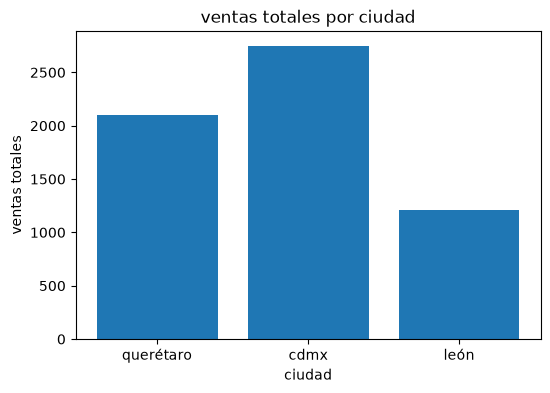

In [11]:
# graficar ventas por ciudad (conversión a pandas para plot rápido)
pdf = aggs.toPandas()
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(pdf["ciudad"], pdf["ventas_totales"])
plt.title("ventas totales por ciudad")
plt.xlabel("ciudad")
plt.ylabel("ventas totales")
plt.show()


## pipeline de ml: clasificación binaria con regresión logística
usaremos datos sintéticos estilo 'titanic' (edad, clase, tarifa, sexo) y el objetivo 'sobrevive'.

8. What is the difference between dask and spark? When it is used each one particularly? 

Dask vs Spark, in short:

Dask — Python-native, mirrors pandas/NumPy/scikit-learn APIs almost exactly, no JVM, lightweight. Best when you're already in the PyData stack and want to scale the same code across cores or a small cluster without rewriting it.
Spark — JVM-based distributed engine (PySpark is a wrapper around it), built for large-scale, fault-tolerant, multi-node processing with a much bigger ecosystem (SQL, MLlib, Structured Streaming, Delta Lake). Best for multi-terabyte, cluster-scale, production big-data pipelines — which is why this notebook uses it.

9. Fuga de datos se refiere a que sin querer damos al modelo informacion que explica muy bien el area objetivo. 

In [12]:
import numpy as np
rng = np.random.default_rng(42)
n = 8000

sexo = rng.integers(0,2,size=n)                  # 0=hombre, 1=mujer
edad = np.clip(rng.normal(30, 12, size=n), 1, 80)
clase = rng.integers(1,4,size=n)                 # 1,2,3
tarifa = np.clip(rng.normal(50, 30, size=n), 5, 300)

# regla sintética: mujeres, clase alta y tarifas altas sobreviven más
logit = -2.0 + 1.0*sexo + 0.5*(4-clase) + 0.01*tarifa - 0.02*(edad-30)
p = 1/(1+np.exp(-logit))
sobrevive = (rng.random(size=n) < p).astype(int)

data_ml = spark.createDataFrame(list(map(lambda a,b,c,d,e: {
    "sexo": int(a), "edad": float(b), "clase": int(c), "tarifa": float(d), "sobrevive": int(e)
}, sexo, edad, clase, tarifa, sobrevive)))

data_ml.show(5)
data_ml.printSchema()


+-----+------------------+----+---------+------------------+
|clase|              edad|sexo|sobrevive|            tarifa|
+-----+------------------+----+---------+------------------+
|    2|17.512789741901944|   0|        1| 26.03999287678893|
|    2|12.040074279325435|   1|        1|31.894882535167373|
|    1| 46.23112691707854|   1|        1|               5.0|
|    1| 59.06937481300195|   0|        1| 58.72538004240762|
|    2| 24.29101056824859|   0|        0| 96.23871415448505|
+-----+------------------+----+---------+------------------+
only showing top 5 rows
root
 |-- clase: long (nullable = true)
 |-- edad: double (nullable = true)
 |-- sexo: long (nullable = true)
 |-- sobrevive: long (nullable = true)
 |-- tarifa: double (nullable = true)



The most important metrics are: 
1. Exactitud. Que proporcion total acerte
2. Precision. De mis positivos, cuantos eran correctos
3. Sensibilidad. De los positivos reales, cuantos encontre
4. F1. Equilibrio entre precision y sensibilidad. 

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder

assembler = VectorAssembler(inputCols=["sexo","edad","clase","tarifa"], outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="sobrevive", maxIter=50)

pipeline = Pipeline(stages=[assembler, scaler, lr])

train, test = data_ml.randomSplit([0.8, 0.2], seed=7)
model = pipeline.fit(train)
pred = model.transform(test)

evaluator = BinaryClassificationEvaluator(labelCol="sobrevive", metricName="areaUnderROC")
roc = evaluator.evaluate(pred)
print("auc-roc:", round(roc, 4))

pred.select("sexo","edad","clase","tarifa","sobrevive","probability","prediction").show(10, truncate=False)


auc-roc: 0.7041
+----+------------------+-----+------------------+---------+----------------------------------------+----------+
|sexo|edad              |clase|tarifa            |sobrevive|probability                             |prediction|
+----+------------------+-----+------------------+---------+----------------------------------------+----------+
|0   |1.0               |1    |72.18725324626764 |1        |[0.3213100218154773,0.6786899781845227] |1.0       |
|0   |1.0               |1    |105.90867131471921|1        |[0.25439899634611857,0.7456010036538814]|1.0       |
|1   |1.0               |1    |22.328396222459986|0        |[0.2198358053283865,0.7801641946716135] |1.0       |
|1   |1.0               |1    |38.17645070602479 |0        |[0.19457503770530218,0.8054249622946978]|1.0       |
|1   |1.0               |1    |35.209565128484016|1        |[0.199130847364818,0.800869152635182]   |1.0       |
|1   |1.0               |1    |65.22520571831083 |1        |[0.15666284876402473

## métricas adicionales: precisión, recall y f1

In [ ]:
from pyspark.sql import functions as F

# calcular matriz de confusión y métricas manualmente
cm = (pred
      .select(F.col("sobrevive").cast("int").alias("y_true"),
              F.col("prediction").cast("int").alias("y_pred"))
     )

tp = cm.filter((F.col("y_true")==1) & (F.col("y_pred")==1)).count()
tn = cm.filter((F.col("y_true")==0) & (F.col("y_pred")==0)).count()
fp = cm.filter((F.col("y_true")==0) & (F.col("y_pred")==1)).count()
fn = cm.filter((F.col("y_true")==1) & (F.col("y_pred")==0)).count()

precision = tp / (tp + fp) if (tp+fp)>0 else 0.0
recall = tp / (tp + fn) if (tp+fn)>0 else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0

print({"tp":tp, "tn":tn, "fp":fp, "fn":fn,
       "precision": round(precision,4),
       "recall": round(recall,4),
       "f1": round(f1,4)})


{'tp': 507, 'tn': 507, 'fp': 268, 'fn': 277, 'precision': 0.6542, 'recall': 0.6467, 'f1': 0.6504}


## Ejercicios para resolver en clase
complete cada celda marcada como `todo` y ejecute para validar su solución.

### ejercicio 1: limpieza y transformación
**instrucciones:** a partir de `df`, convierta `fecha` a tipo date, elimine registros con `ventas` nulas y agregue una columna `mes` con el número de mes. muestre el conteo por `mes`.

In [ ]:
# todo: complete los pasos indicados
# 1) convertir 'fecha' a date
# 2) filtrar registros con ventas no nulas
# 3) agregar columna 'mes' = month(fecha)
# 4) contar filas por 'mes'

from pyspark.sql import functions as F

# su solución aquí
# df_sol = (...)

# ejemplo de validación (no modifique)
# df_sol.groupBy("mes").count().orderBy("mes").show()


### ejercicio 2: joins
**instrucciones:** cree un dataframe `bonos` con columnas `ciudad` y `bono` (por ejemplo, 0.05 para cdmx, 0.10 para querétaro, 0.07 para león). haga un left join con `df_imputado` y calcule `ventas_bonificadas = ventas * (1 + bono)`. muestre las primeras 5 filas.

In [ ]:
# todo: construya 'bonos' y haga el left join
# tips: spark.createDataFrame([...], ['ciudad','bono'])

# su solución aquí


### ejercicio 3: ventanas
**instrucciones:** calcule un promedio móvil de 3 observaciones de `ventas` por `ciudad` ordenado por `fecha`. use `rowsBetween(-2, 0)`.

In [ ]:
# todo: defina la ventana y agregue una columna 'prom_movil_3'

# su solución aquí


### ejercicio 4: udf
**instrucciones:** escriba una udf que etiquete `ventas` como `bajo` (<500), `medio` (500–1500) o `alto` (>1500). agregue la columna `segmento` al dataframe `df_imputado`.

In [ ]:
# todo: udf de segmentación

# su solución aquí


### ejercicio 5: pipeline de clasificación
**instrucciones:** sobre `data_ml`, agregue una columna binaria `vip` con valor 1 si `tarifa > 120` y 0 en otro caso. incluya `vip` como feature adicional en el pipeline y compare el auc-roc contra el modelo base mostrado arriba.

In [ ]:
# todo: modificar pipeline para incluir 'vip' como nueva característica
# pasos:
# - withColumn('vip', (F.col('tarifa') > 120).cast('int'))
# - actualizar VectorAssembler para incluir 'vip'
# - reentrenar y evaluar

# su solución aquí


## cierre
- repasamos lectura, transformaciones, agregaciones, joins y ventanas
- implementamos udfs y un pipeline de clasificación
- resolvimos métricas básicas y planteamos ejercicios prácticos

**posibles extensiones**
- agregar validación cruzada con k-folds
- usar regresión para un objetivo continuo
- conectar con fuentes externas (s3, gcs, kafka)


## detener spark (opcional)

# Uso de PySpark con datos reales: clasificación, regresión y análisis exploratorio automático

_Notebook Colab con ejemplos resueltos, comentarios, ejercicios y reporte en html_

> Todo el contenido respeta el uso de mayúsculas y minúsculas en español. Los títulos usan mayúscula solo en la primera palabra, y los párrafos inician con mayúscula y continúan en minúsculas, salvo nombres propios.

## Preparación del entorno (Google Colab)

In [ ]:
# Instala PySpark si es necesario y (opcional) monta Google Drive.
# Si no deseas usar Drive, puedes ignorar la última parte.

%pip install -q pyspark==3.5.1

## Iniciar Spark Session

In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("pyspark-datos-reales-eda-clas-reg")
         .getOrCreate())

spark


## Datos reales: NYC Yellow Taxi (enero 2023)

In [ ]:
import os, tempfile, urllib.request

url = "https://github.com/ulises1229/DataAnalisysBigData_BLOQUE/raw/main/data/yellow_tripdata_2023-01.parquet"
base_dir = tempfile.mkdtemp(prefix="nyc_yellow_real_")
local_parquet = os.path.join(base_dir, "yellow_tripdata_2023-01.parquet")

print("Descargando...", url)
urllib.request.urlretrieve(url, local_parquet)
print("Archivo guardado en:", local_parquet)

df = spark.read.parquet(local_parquet)
df.printSchema()
df.show(5, truncate=False)


Descargando... https://github.com/ulises1229/DataAnalisysBigData_BLOQUE/raw/main/data/yellow_tripdata_2023-01.parquet
Archivo guardado en: /tmp/nyc_yellow_real_4_r69rm2/yellow_tripdata_2023-01.parquet
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge

## Limpieza y construcción de variables

In [ ]:
from pyspark.sql import functions as F

cols = ["tpep_pickup_datetime","tpep_dropoff_datetime","passenger_count","trip_distance",
        "fare_amount","tip_amount","total_amount","payment_type","VendorID","RatecodeID"]
df_sel = df.select(*[c for c in cols if c in df.columns])

df_feat = (df_sel
    .withColumn("pickup_ts", F.to_timestamp("tpep_pickup_datetime"))
    .withColumn("dropoff_ts", F.to_timestamp("tpep_dropoff_datetime"))
    .withColumn("passenger_count", F.col("passenger_count").cast("double"))
    .withColumn("trip_distance", F.col("trip_distance").cast("double"))
    .withColumn("fare_amount", F.col("fare_amount").cast("double"))
    .withColumn("tip_amount", F.col("tip_amount").cast("double"))
    .withColumn("total_amount", F.col("total_amount").cast("double"))
    .filter(F.col("pickup_ts").isNotNull() & F.col("dropoff_ts").isNotNull())
    .filter(F.col("trip_distance").isNotNull() & (F.col("trip_distance") > 0.1) & (F.col("trip_distance") < 100))
    .filter(F.col("fare_amount").isNotNull() & (F.col("fare_amount") >= 2) & (F.col("fare_amount") < 500))
    .filter(F.col("total_amount").isNotNull() & (F.col("total_amount") > 0))
    .withColumn("duration_min", (F.unix_timestamp("dropoff_ts") - F.unix_timestamp("pickup_ts"))/60.0)
    .filter(F.col("duration_min") > 1)
    .withColumn("hour", F.hour("pickup_ts").cast("int"))
    .withColumn("dow_spark", F.dayofweek("pickup_ts"))
    .withColumn("dow", F.when(F.col("dow_spark")==1, F.lit(7)).otherwise(F.col("dow_spark")-1).cast("int"))
    .drop("dow_spark")
    .withColumn("speed_kmh", (F.col("trip_distance") / (F.col("duration_min")/60.0)))
    .filter((F.col("speed_kmh") > 3) & (F.col("speed_kmh") < 120))
    .cache()
)

print("Filas tras limpieza:", df_feat.count())
df_feat.select("pickup_ts","trip_distance","duration_min","speed_kmh","hour","dow",
               "fare_amount","tip_amount","total_amount").show(5, truncate=False)


Filas tras limpieza: 2971922
+-------------------+-------------+------------------+------------------+----+---+-----------+----------+------------+
|pickup_ts          |trip_distance|duration_min      |speed_kmh         |hour|dow|fare_amount|tip_amount|total_amount|
+-------------------+-------------+------------------+------------------+----+---+-----------+----------+------------+
|2023-01-01 00:32:10|0.97         |8.433333333333334 |6.901185770750987 |0   |7  |9.3        |0.0       |14.3        |
|2023-01-01 00:55:08|1.1          |6.316666666666666 |10.448548812664908|0   |7  |7.9        |4.0       |16.9        |
|2023-01-01 00:25:04|2.51         |12.75             |11.811764705882352|0   |7  |14.9       |15.0      |34.9        |
|2023-01-01 00:03:48|1.9          |9.616666666666667 |11.854419410745232|0   |7  |12.1       |0.0       |20.85       |
|2023-01-01 00:10:29|1.43         |10.833333333333334|7.92              |0   |7  |11.4       |3.28      |19.68       |
+------------------

## Análisis exploratorio automático y reporte en html

Generaremos un reporte en **html** de forma automática. Tienes tres opciones: 1) ydata‑profiling (antes pandas‑profiling), 2) Sweetviz, y 3) un reporte básico sin librerías externas.

### Opción 1: ydata‑profiling (recomendado para pandas)

In [ ]:
# Esta opción requiere convertir una muestra del DataFrame de Spark a pandas.
# Para no agotar memoria, se recomienda muestrear y limitar a ~100k filas.
# Ejecuta la instalación si estás en Colab.

!pip install -q scipy==1.10.1
!pip install -q ydata-profiling

from pyspark.sql import functions as F
from pyspark.sql import DataFrame

# Muestra estratificada aproximada y límite de filas
fraccion = 0.5  # ajusta si lo necesitas
df_sample = df_feat.sample(withReplacement=False, fraction=fraccion, seed=2025).limit(1000000)

# Conversión a pandas
pdf = df_sample.toPandas()

# Generación del reporte
from ydata_profiling import ProfileReport
profile = ProfileReport(pdf, title="Reporte EDA NYC Yellow Taxi (muestra)", explorative=True)
out_html = "/content/reporte_eda_ydata_profiling.html"
profile.to_file(out_html)
print("Reporte generado:", out_html)

ERROR: Ignored the following yanked versions: 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.11.0 Requires-Python <3.13,>=3.9; 1.11.0rc1 Requires-Python <3.13,>=3.9; 1.11.0rc2 Requires-Python <3.13,>=3.9; 1.11.1 Requires-Python <3.13,>=3.9; 1.11.2 Requires-Python <3.13,>=3.9; 1.11.3 Requires-Python <3.13,>=3.9; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >

/tmp/ipykernel_3502/2389903983.py:19: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:01<00:00,  8.38it/s]
/usr/local/lib/python3.13/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 6 6 6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.13/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9 9 9 ... 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte generado: /content/reporte_eda_ydata_profiling.html


# Uso de PySpark con datos reales: clasificación y regresión



## Limpieza y construcción de variables

En esta sección convertimos tipos, filtramos valores anómalos y construimos variables de tiempo y velocidad. Esto mejora la calidad del modelo y reduce ruido.

In [ ]:
from pyspark.sql import functions as F

# Seleccionamos columnas de interés (si alguna no existe, se omite de forma segura).
cols = ["tpep_pickup_datetime","tpep_dropoff_datetime","passenger_count","trip_distance",
        "fare_amount","tip_amount","total_amount","payment_type","VendorID","RatecodeID"]
df_sel = df.select(*[c for c in cols if c in df.columns])

# Construimos un DataFrame con casting y filtros de sanidad (valores razonables).
df_feat = (df_sel
    # 1) Convertir a timestamp
    .withColumn("pickup_ts", F.to_timestamp("tpep_pickup_datetime"))
    .withColumn("dropoff_ts", F.to_timestamp("tpep_dropoff_datetime"))
    # 2) Asegurar tipos numéricos
    .withColumn("passenger_count", F.col("passenger_count").cast("double"))
    .withColumn("trip_distance", F.col("trip_distance").cast("double"))
    .withColumn("fare_amount", F.col("fare_amount").cast("double"))
    .withColumn("tip_amount", F.col("tip_amount").cast("double"))
    .withColumn("total_amount", F.col("total_amount").cast("double"))
    # 3) Filtros de presencia y rangos razonables
    .filter(F.col("pickup_ts").isNotNull() & F.col("dropoff_ts").isNotNull())
    .filter(F.col("trip_distance").isNotNull() & (F.col("trip_distance") > 0.1) & (F.col("trip_distance") < 100))
    .filter(F.col("fare_amount").isNotNull() & (F.col("fare_amount") >= 2) & (F.col("fare_amount") < 500))
    .filter(F.col("total_amount").isNotNull() & (F.col("total_amount") > 0))
    # 4) Variables derivadas
    .withColumn("duration_min", (F.unix_timestamp("dropoff_ts") - F.unix_timestamp("pickup_ts"))/60.0)
    .filter(F.col("duration_min") > 1)  # Descartamos viajes extremadamente cortos
    .withColumn("hour", F.hour("pickup_ts").cast("int"))
    # Reemplazo robusto de 'dow': usamos dayofweek() (1=domingo,...,7=sábado) y mapeamos a ISO (1=lunes,...,7=domingo).
    .withColumn("dow_spark", F.dayofweek("pickup_ts"))
    .withColumn("dow", F.when(F.col("dow_spark")==1, F.lit(7)).otherwise(F.col("dow_spark")-1).cast("int"))
    .drop("dow_spark")
    .withColumn("speed_kmh", (F.col("trip_distance") / (F.col("duration_min")/60.0)))
    .filter((F.col("speed_kmh") > 3) & (F.col("speed_kmh") < 120))  # Límites razonables de velocidad
    .cache()
)

print("Filas tras limpieza:", df_feat.count())
df_feat.select("pickup_ts","trip_distance","duration_min","speed_kmh","hour","dow",
               "fare_amount","tip_amount","total_amount").show(5, truncate=False)


Filas tras limpieza: 2971922
+-------------------+-------------+------------------+------------------+----+---+-----------+----------+------------+
|pickup_ts          |trip_distance|duration_min      |speed_kmh         |hour|dow|fare_amount|tip_amount|total_amount|
+-------------------+-------------+------------------+------------------+----+---+-----------+----------+------------+
|2023-01-01 00:32:10|0.97         |8.433333333333334 |6.901185770750987 |0   |7  |9.3        |0.0       |14.3        |
|2023-01-01 00:55:08|1.1          |6.316666666666666 |10.448548812664908|0   |7  |7.9        |4.0       |16.9        |
|2023-01-01 00:25:04|2.51         |12.75             |11.811764705882352|0   |7  |14.9       |15.0      |34.9        |
|2023-01-01 00:03:48|1.9          |9.616666666666667 |11.854419410745232|0   |7  |12.1       |0.0       |20.85       |
|2023-01-01 00:10:29|1.43         |10.833333333333334|7.92              |0   |7  |11.4       |3.28      |19.68       |
+------------------

## Exploración rápida

Revisaremos el número de viajes por hora y por día de la semana. Esto permite detectar horarios pico y patrones temporales.

In [ ]:
aggs_h = (df_feat.groupBy("hour")
          .agg(F.count("*").alias("n_viajes"),
               F.round(F.avg("trip_distance"),2).alias("dist_prom"),
               F.round(F.avg("duration_min"),2).alias("dur_prom"),
               F.round(F.avg("fare_amount"),2).alias("tarifa_prom"))
          .orderBy("hour"))
aggs_h.show(24)

aggs_dow = (df_feat.groupBy("dow")
            .agg(F.count("*").alias("n_viajes"),
                 F.round(F.avg("trip_distance"),2).alias("dist_prom"),
                 F.round(F.avg("total_amount"),2).alias("total_prom"))
            .orderBy("dow"))
aggs_dow.show()


+----+--------+---------+--------+-----------+
|hour|n_viajes|dist_prom|dur_prom|tarifa_prom|
+----+--------+---------+--------+-----------+
|   0|   82041|     4.05|   13.58|      19.84|
|   1|   57572|     3.54|   12.64|      17.98|
|   2|   40311|     3.29|   12.08|      16.96|
|   3|   26044|     3.59|   12.18|       18.0|
|   4|   16544|     4.79|   13.49|      22.45|
|   5|   16875|     6.05|   14.69|      26.53|
|   6|   42206|      4.8|   14.48|      22.17|
|   7|   84384|     3.69|   14.42|      18.98|
|   8|  113610|     3.09|   14.32|      17.52|
|   9|  127171|     3.11|   14.21|      17.62|
|  10|  139338|     3.15|   14.25|       17.7|
|  11|  149512|     3.02|   14.26|      17.41|
|  12|  164689|     3.12|   14.39|      17.75|
|  13|  172803|     3.31|   15.05|      18.45|
|  14|  185695|     3.59|   16.39|       19.7|
|  15|  190235|     3.43|   16.42|      19.26|
|  16|  189563|     3.53|   16.53|       19.5|
|  17|  203214|     3.31|    16.0|      18.63|
|  18|  20955

## Clasificación: propina alta (tip_ratio > 0.2) con Logistic Regression y árbol

Definimos la etiqueta como `propina_alta = tip_amount / fare_amount > 0.2`. Entrenaremos dos modelos para comparar: uno lineal (Logistic Regression) y uno no lineal (árbol de decisión).

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# 1) Crear etiqueta
df_cls = (df_feat
          .filter(F.col("fare_amount") > 0)
          .withColumn("tip_ratio", (F.col("tip_amount") / F.col("fare_amount")))
          .fillna({"tip_ratio": 0.0})
          .withColumn("propina_alta", (F.col("tip_ratio") > 0.2).cast("int"))
         )

# 2) Seleccionar variables predictoras
feature_cols = ["passenger_count","trip_distance","fare_amount","total_amount",
                "hour","dow","duration_min","speed_kmh"]

# Drop rows with nulls in feature columns before assembling
df_cls = df_cls.na.drop(subset=feature_cols)

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features")

# 3) Modelos
lr = LogisticRegression(featuresCol="features", labelCol="propina_alta", maxIter=120)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="propina_alta", maxDepth=12)

pipe_lr = Pipeline(stages=[assembler, scaler, lr])
pipe_dt = Pipeline(stages=[assembler, scaler, dt])

# 4) Partición entrenamiento/prueba
train, test = df_cls.randomSplit([0.8, 0.2], seed=2025)

# 5) Entrenamiento
m_lr = pipe_lr.fit(train)
m_dt = pipe_dt.fit(train)

# 6) Predicciones
p_lr = m_lr.transform(test)
p_dt = m_dt.transform(test)

# 7) Métricas
auc = BinaryClassificationEvaluator(labelCol="propina_alta", metricName="areaUnderROC")
acc = MulticlassClassificationEvaluator(labelCol="propina_alta", metricName="accuracy")

print({"auc_lr": round(auc.evaluate(p_lr),4), "acc_lr": round(acc.evaluate(p_lr),4)})
print({"auc_dt": round(auc.evaluate(p_dt),4), "acc_dt": round(acc.evaluate(p_dt),4)})

# Matriz de confusión (LR)
print("Matriz de confusión (LR):")
(p_lr.groupBy("propina_alta","prediction").count().orderBy("propina_alta","prediction")).show()

# Árbol entrenado (resumen)
print("Árbol (resumen):")
print(m_dt.stages[-1].toDebugString[:1500])

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/usr/local/lib/python3.13/dist-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/socket.py", line 723, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt


KeyboardInterrupt: 

## Regresión: predicción de total_amount (Linear y GBT)

Ahora predeciremos el monto total del viaje como variable continua. Compararemos un modelo lineal con un ensamble de árboles (GBT).

In [ ]:
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler

# 1) Seleccionamos columnas
df_reg = df_feat.select("total_amount","passenger_count","trip_distance","fare_amount",
                        "hour","dow","duration_min","speed_kmh").filter(F.col("total_amount").isNotNull())

# 2) Ensamblado y escalado
assembler_r = VectorAssembler(inputCols=["passenger_count","trip_distance","fare_amount",
                                         "hour","dow","duration_min","speed_kmh"],
                              outputCol="features_raw",handleInvalid="skip")
scaler_r = StandardScaler(inputCol="features_raw", outputCol="features")

# 3) Modelos
lr_r = LinearRegression(featuresCol="features", labelCol="total_amount", maxIter=100)
gbt = GBTRegressor(featuresCol="features", labelCol="total_amount", maxDepth=6, maxIter=60, stepSize=0.1)

from pyspark.ml import Pipeline
pipe_lr_r = Pipeline(stages=[assembler_r, scaler_r, lr_r])
pipe_gbt = Pipeline(stages=[assembler_r, scaler_r, gbt])

# 4) Partición
train_r, test_r = df_reg.randomSplit([0.8,0.2], seed=77)

# 5) Entrenamiento
m_lr_r = pipe_lr_r.fit(train_r)
m_gbt = pipe_gbt.fit(train_r)

# 6) Evaluación
p_lr_r = m_lr_r.transform(test_r)
p_gbt = m_gbt.transform(test_r)

rmse = RegressionEvaluator(labelCol="total_amount", metricName="rmse").evaluate(p_lr_r)
r2   = RegressionEvaluator(labelCol="total_amount", metricName="r2").evaluate(p_lr_r)
rmse_gbt = RegressionEvaluator(labelCol="total_amount", metricName="rmse").evaluate(p_gbt)
r2_gbt   = RegressionEvaluator(labelCol="total_amount", metricName="r2").evaluate(p_gbt)

print({"rmse_lr": round(rmse,2), "r2_lr": round(r2,3)})
print({"rmse_gbt": round(rmse_gbt,2), "r2_gbt": round(r2_gbt,3)})


## Tuning de hiperparámetros con TrainValidationSplit

Ajustaremos `regParam` y `elasticNetParam` de Logistic Regression para mejorar el AUC.

In [ ]:
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

param_grid = (ParamGridBuilder()
              .addGrid(lr.regParam, [0.0, 0.01, 0.1])
              .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
              .build())

tvs = TrainValidationSplit(estimator=pipe_lr,
                           estimatorParamMaps=param_grid,
                           evaluator=BinaryClassificationEvaluator(labelCol="propina_alta", metricName="areaUnderROC"),
                           trainRatio=0.8,
                           parallelism=2)

tvs_model = tvs.fit(train)
pred_tuned = tvs_model.transform(test)
print("AUC ajustado (LR):", round(BinaryClassificationEvaluator(labelCol='propina_alta',metricName='areaUnderROC').evaluate(pred_tuned),4))


## Ejercicios para resolver en clase

- Ejercicio 1: Añade `is_weekend` y `night` como variables y compara AUC y accuracy en clasificación.
- Ejercicio 2: Entrena `DecisionTreeClassifier` con `maxDepth ∈ {3,5,7,9}` y grafica AUC vs profundidad.
- Ejercicio 3: Usa `TrainValidationSplit` para ajustar `regParam` en Logistic Regression y reporta el mejor AUC.
- Ejercicio 4: Entrena `GBTRegressor` variando `maxDepth` y `maxIter`; compara RMSE y R² con Linear Regression.

## Cierre

Repasamos un flujo completo con datos reales: ingesta, limpieza, ingeniería de variables, exploración, modelos de clasificación y regresión, métricas y tuning. Recuerda que la calidad del preprocesamiento y las variables es clave para el desempeño.

### Ejercicios adicionales para practicar

- Ejercicio 5: Calcular la tarifa promedio (`fare_amount`) por hora del día y graficar los resultados.
- Ejercicio 6: Determinar las 10 ubicaciones de recogida (`PULocationID`) más frecuentes y mostrar su conteo.
- Ejercicio 7: Calcular la duración promedio del viaje (`duration_min`) para cada tipo de pago (`payment_type`).
- Ejercicio 8: Identificar el día de la semana con la mayor distancia promedio de viaje.
- Ejercicio 9: Crear una columna `rango_tarifa` categorizando `fare_amount` en "bajo" (<10), "medio" (10-30) y "alto" (>30).

## Detener Spark (opcional)

In [ ]:
# Cuando termines, libera recursos del driver y ejecutores.
#spark.stop()
